In [1]:
# ── CELL 1: IMPORTS ──────────────────────────────────────────
import os, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
warnings.filterwarnings('ignore')

In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as z:
    z.extractall("dataset")

DATA_PATH = "dataset/data"

In [5]:
# ── CELL 2: LOAD + CORRUPT CHECK ─────────────────────────────
IMG_SIZE = (64, 64)
X, y, corrupt = [], [], 0

DATA_PATH = "dataset/data"   # change if local
classes   = sorted(os.listdir(DATA_PATH))        # ['with_mask', 'without_mask']

for label, cls in enumerate(classes):
    for fname in os.listdir(f"{DATA_PATH}/{cls}"):
        try:
            img = Image.open(f"{DATA_PATH}/{cls}/{fname}").convert("RGB").resize(IMG_SIZE)
            X.append(np.array(img))
            y.append(label)
        except:
            corrupt += 1

X, y = np.array(X), np.array(y)
print(f"Loaded: {len(X)} | Corrupt: {corrupt} | Classes: {classes}")

Loaded: 7553 | Corrupt: 0 | Classes: ['with_mask', 'without_mask']


In [15]:
# Train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [16]:
# ── CELL 4: AUGMENT + NORMALIZE ──────────────────────────────
X_aug   = np.array([img[:, ::-1, :] for img in X_train])  # horizontal flip
X_train = np.concatenate([X_train, X_aug])   / 255.0       # doubles + normalizes
y_train = np.concatenate([y_train, y_train])
X_test  = X_test / 255.0

In [17]:
# ── CELL 5: FEATURE EXTRACTION ───────────────────────────────
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2hsv, rgb2gray

def extract(X):
    feats = []
    for img in X:
        gray     = rgb2gray(img)
        hog_f    = hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2,2))  # SHAPE
        hsv      = rgb2hsv(img)
        colour_f = np.concatenate([
                       np.histogram(hsv[:,:,0], bins=16)[0].astype(float),  # COLOUR: hue
                       np.histogram(hsv[:,:,1], bins=16)[0].astype(float),  # COLOUR: saturation
                       np.array([img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()])  # COLOUR: rgb means
                   ])
        lbp_f    = np.histogram(local_binary_pattern(gray, 8, 1, 'uniform'), bins=10)[0].astype(float)  # TEXTURE
        feats.append(np.concatenate([hog_f, colour_f, lbp_f]))
    return np.array(feats)

print("Extracting features...")
F_train = extract(X_train)
F_test  = extract(X_test)

scaler  = StandardScaler()
F_train = scaler.fit_transform(F_train)
F_test  = scaler.transform(F_test)

Extracting features...


In [19]:
# ── CELL 6: TRAIN SVM ────────────────────────────────────────
model = SVC(kernel='rbf', C=10.0, probability=True)    # less regularization

model.fit(F_train, y_train)
preds = model.predict(F_test)

print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=classes))

Accuracy: 0.9069
              precision    recall  f1-score   support

   with_mask       0.90      0.91      0.91      1118
without_mask       0.91      0.90      0.91      1148

    accuracy                           0.91      2266
   macro avg       0.91      0.91      0.91      2266
weighted avg       0.91      0.91      0.91      2266



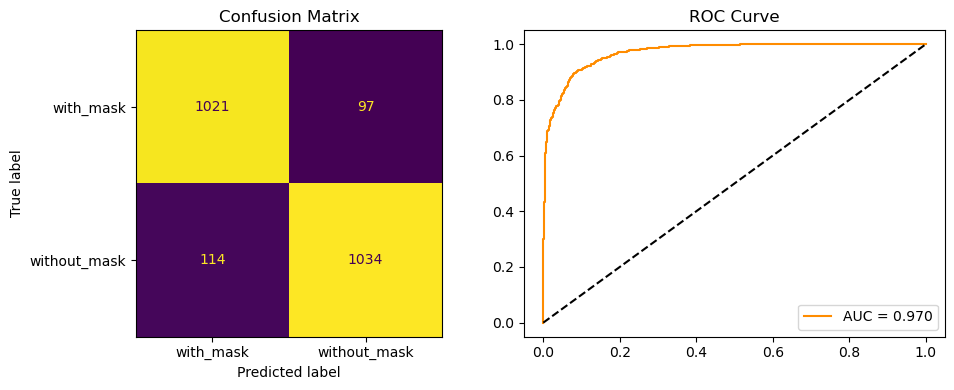

In [21]:
# ── CELL 7: PLOTS ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                       display_labels=classes).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(F_test)[:, 1])
axes[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color='darkorange')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()